# **Project Name**    - Voyage Analytics: Integrating MLOps in Travel



##### **Project Type**    - MLOps (part 3 Recommendation Engine)
##### **Contribution**    - Individual
##### **Name -** Yashman Singh

# Project Summary

This project develops a collaborative filtering-based hotel recommendation system. In today's competitive travel market, personalized recommendations are crucial for enhancing user experience and driving business growth. This system leverages historical user interaction data to identify similar users and recommend hotels that those similar users have enjoyed but the current user has not yet experienced. The core of this system is the use of cosine similarity to measure the similarity between users based on their hotel booking patterns.

The project begins with data loading and an in-depth exploratory data analysis (EDA) to understand the dataset's structure, identify key features, and visualize booking trends. Data wrangling steps include converting date columns to datetime objects and removing duplicate entries to ensure data quality. A user-hotel matrix is then constructed, representing each user's total spending on various hotels. This matrix forms the foundation for calculating user-to-user similarity.

The recommendation algorithm identifies the top 'N' most similar users to a given target user. It then aggregates the hotels booked by these similar users, filtering out any hotels the target user has already booked. To ensure a robust recommendation experience, a fallback mechanism is implemented: if insufficient recommendations are found through similar users, popular hotels (based on overall revenue) are suggested. This hybrid approach ensures that recommendations are always available, even for users with limited interaction history or those who have explored most available options.

Finally, the trained similarity matrix and user-hotel matrix are saved using `joblib`, allowing for easy deployment and future use of the recommendation system without re-computing these complex structures. This project demonstrates a practical application of machine learning in providing personalized travel suggestions, ultimately aiming to improve user satisfaction and increase hotel bookings.

# Problem Statement

In the hotel industry, providing personalized recommendations to users is vital for improving engagement and sales. Traditional recommendation methods often struggle with data sparsity or fail to capture the nuanced preferences of individual users. This project aims to address the challenge of delivering relevant hotel recommendations by developing a collaborative filtering system. The system should accurately identify user preferences based on past booking behavior and suggest new hotels that align with these preferences, while also providing a robust fallback for cases where direct similar-user recommendations are limited.

# Import Libraries

This section imports all necessary Python libraries for data manipulation, numerical operations, visualization, machine learning model building, and utility functions. The libraries include `pandas` and `numpy` for data handling, `matplotlib.pyplot` and `seaborn` for data visualization, `sklearn` modules for model selection, preprocessing, pipelines, ensemble models, and metrics, and `joblib` for model persistence.

In [1]:
url3 = "https://raw.githubusercontent.com/YashmanSingh2003/Voyage-Analytics-MLOps-/refs/heads/main/dataset/hotels.csv"

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import joblib

# Load Dataset

The dataset, `hotels.csv`, is loaded into a pandas DataFrame. This dataset contains historical booking information, including `travelCode`, `userCode`, `name` (hotel name), `place`, `days` (number of days booked), `price` (price per day), `total` (total booking amount), and `date` of booking. The `url3` variable holds the raw GitHub URL for direct loading.

In [3]:
hotels_df = pd.read_csv(url3)
hotels_df.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


# Understanding the Dataset

Before proceeding with any analysis or model building, it's crucial to understand the characteristics of the dataset. This section explores the dataset's dimensions, column information, and the number of unique entities within key categorical columns.

- **Dataset shape:** The `hotels_df.shape` output indicates that the dataset contains `40552` rows and `8` columns, providing a substantial amount of booking records.
- **Columns:** The `hotels_df.columns` output lists the names of all columns: `travelCode`, `userCode`, `name`, `place`, `days`, `price`, `total`, and `date`. These columns capture essential information about each hotel booking.
- **Number of unique users:** The `df['userCode'].nunique()` output shows `1310` unique users in the dataset. This is a critical metric for a collaborative filtering system, as it defines the number of entities for whom recommendations will be generated.
- **Number of unique hotels:** The `df['name'].nunique()` output indicates `9` unique hotels. This relatively small number of hotels suggests that the dataset might represent a specific market or a limited selection of accommodations.
- **Number of unique destinations:** The `df['place'].nunique()` output reveals `9` unique destinations. This aligns with the number of unique hotels, suggesting that each hotel might be located in a distinct destination or that there's a one-to-one mapping between hotels and primary destinations within this dataset.

In [4]:
hotels_df.shape

(40552, 8)

In [5]:
hotels_df.columns

Index(['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total',
       'date'],
      dtype='object')

In [6]:
hotels_df.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [7]:
df= hotels_df.copy()

In [8]:
df.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [ ]:
df.shape

(40552, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


In [ ]:
df.isnull().sum()

,0
travelCode,0
userCode,0
name,0
place,0
days,0
price,0
total,0
date,0


In [ ]:
df['date'] = pd.to_datetime(
    df['date'],
    format='%m/%d/%Y'
)

In [ ]:
df.drop_duplicates(inplace=True)

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is a critical step to understand the underlying patterns, distributions, and relationships within the dataset. Through visualization, we can gain insights that inform feature engineering and model development.

In [ ]:
print(df['name'].nunique())
print(df['userCode'].nunique())
print(df['place'].nunique())

9
1310
9


# Data Wrangling

This section focuses on cleaning and preparing the dataset for analysis and model building. Data wrangling ensures that the data types are appropriate and that there are no redundant entries that could skew our results.

-   **Date conversion into datetime format:** The `date` column, initially an object (string) type, is converted to a datetime object using `pd.to_datetime` with the specified format `'%m/%d/%Y'`. This conversion is essential for any time-series analysis or feature engineering based on dates (e.g., extracting month, year, or day of the week).
-   **Duplicate removal:** The `df.drop_duplicates(inplace=True)` command is used to remove any rows that are exact duplicates across all columns. This ensures that each booking record is unique and prevents overcounting or biased analysis due to repeated entries.
-   **Why no identifier columns were removed:** Identifier columns like `travelCode` and `userCode` are crucial for the collaborative filtering approach. `userCode` is the primary key for identifying users and building the user-hotel matrix. `travelCode` uniquely identifies each travel instance, which, although not directly used in the current collaborative filtering logic, could be valuable for more complex analyses or for ensuring the uniqueness of records during data wrangling. Columns such as `name` and `place` are also vital for generating recommendations and understanding hotel and destination characteristics. Therefore, no identifier or descriptive columns were removed at this stage.

In [ ]:
# Create User-Hotel Matrix

user_hotel_matrix = pd.pivot_table(
    df,
    index='userCode',
    columns='name',
    values='total',
    aggfunc='sum',
    fill_value=0
)

user_hotel_matrix.head()

name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,2191.14,1530.1,1564.15,2185.92,990.48,301.95,165.99,5004.79,2080.40
1,0.00,139.1,0.00,0.00,247.62,0.00,0.00,0.00,0.00
2,5634.36,834.6,1876.98,1700.16,1238.10,1207.80,1161.93,2897.51,3536.68
3,6886.44,1808.3,5630.94,6072.00,1238.10,1328.58,2489.85,3687.74,832.16
4,5634.36,2364.7,6569.43,3886.08,2228.58,724.68,4481.73,3687.74,2080.40


# Recommendation System

The core of this project is a user-based collaborative filtering recommendation system. This system identifies users with similar tastes and preferences and recommends items (hotels) that those similar users have interacted with but the target user has not.

### Collaborative Filtering Explained
Collaborative filtering is a technique used by recommendation systems to make automatic predictions (filtering) about the interests of a user by collecting preferences or taste information from many users (collaborating). The underlying assumption is that if two users have similar tastes in the past (e.g., booked similar hotels), they will likely have similar tastes in the future.

### Cosine Similarity Explained
Cosine similarity is a metric used to measure how similar two non-zero vectors are. It measures the cosine of the angle between two vectors. A cosine similarity of 1 means the vectors are identical (pointing in the same direction), 0 means they are orthogonal (no similarity), and -1 means they are opposite. In our case, the vectors are the rows of the user-hotel matrix, where each dimension represents a hotel and the value represents the total amount spent. A higher cosine similarity between two users indicates more similar hotel booking patterns.

### Creation of `user_similarity` Matrix
The `user_similarity` matrix is created by applying the `cosine_similarity` function from `sklearn.metrics.pairwise` to the `user_hotel_matrix`. Each entry `(i, j)` in this `user_similarity` matrix represents the cosine similarity between `user i` and `user j`. This matrix quantifies how similar each user is to every other user in the dataset.

### Recommendation Logic
The `recommend_hotels` function implements the following steps to generate recommendations for a given `user_id`:
1.  **Find top 5 similar users:** It retrieves the target `user_id`'s row from the `user_similarity_df`, sorts the similarities in descending order, and selects the top 5 most similar users (excluding the user themselves, as their similarity to themselves is always 1).
2.  **Hotels already booked by target user:** It identifies all hotels that the `user_id` has already booked from the original DataFrame `df`.
3.  **Collect hotels from similar users:** For each of the top similar users, it identifies all hotels they have booked.
4.  **Remove hotels already visited by target user:** It then subtracts the hotels already booked by the target user from the set of hotels booked by similar users. This ensures that only new, unvisited hotels are recommended.
5.  **Return top recommendations:** Finally, it returns a list of these unvisited hotels as recommendations, up to the specified `n_recommendations` (defaulting to 5).

### Fallback Mechanism using Popular Hotels
A critical enhancement to the recommendation system is the fallback mechanism. If the primary collaborative filtering approach (finding hotels from similar users that the target user hasn't visited) yields fewer than `n_recommendations` hotels, the system resorts to recommending globally popular hotels. This ensures that the user always receives a sufficient number of recommendations.

-   **Popular hotels list:** A `popular_hotels` Series (computed earlier) is used, which lists hotels sorted by their total revenue in descending order.
-   **Appending popular hotels:** The system iterates through the `popular_hotels` list, adding hotels to the recommendations only if the target user has not already booked them and they are not already in the `recommendations` list. This continues until `n_recommendations` are met.
-   **Edge case handling:** An additional edge case is handled where a user might have already booked *all* available hotels. In such a scenario, a specific message "User has already booked all available hotels" is returned.

In [ ]:
user_similarity = cosine_similarity(
    user_hotel_matrix
)

In [ ]:
print("Matrix Shape:", user_hotel_matrix.shape)

user_hotel_matrix.head()

Matrix Shape: (1310, 9)


name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,2191.14,1530.1,1564.15,2185.92,990.48,301.95,165.99,5004.79,2080.40
1,0.00,139.1,0.00,0.00,247.62,0.00,0.00,0.00,0.00
2,5634.36,834.6,1876.98,1700.16,1238.10,1207.80,1161.93,2897.51,3536.68
3,6886.44,1808.3,5630.94,6072.00,1238.10,1328.58,2489.85,3687.74,832.16
4,5634.36,2364.7,6569.43,3886.08,2228.58,724.68,4481.73,3687.74,2080.40


In [ ]:
# Calculate Cosine Similarity

user_similarity = cosine_similarity(
    user_hotel_matrix
)

print(user_similarity.shape)

(1310, 1310)


In [ ]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_hotel_matrix.index,
    columns=user_hotel_matrix.index
)

user_similarity_df.head()

userCode,0,1,2,3,4,5,6,7,8,9,...,1330,1331,1332,1333,1334,1335,1336,1337,1338,1339
userCode,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.240864,0.819146,0.776142,0.768412,0.875010,0.726027,0.484499,0.702071,0.902838,...,0.727401,0.770834,0.775099,0.753074,0.293121,0.754673,0.147910,0.660790,0.147910,0.789156
1,0.240864,1.000000,0.185878,0.164295,0.262939,0.130910,0.488245,0.367790,0.221381,0.342983,...,0.478849,0.672822,0.385588,0.516135,0.886242,0.324837,0.871856,0.129509,0.871856,0.380279
2,0.819146,0.185878,1.000000,0.844402,0.842357,0.695090,0.794799,0.466313,0.691912,0.809831,...,0.614371,0.515623,0.666554,0.579244,0.263450,0.639432,0.154640,0.484446,0.154640,0.631251
3,0.776142,0.164295,0.844402,1.000000,0.949031,0.621927,0.851833,0.729696,0.909011,0.785360,...,0.688325,0.559354,0.700378,0.678036,0.335357,0.714211,0.103514,0.736508,0.103514,0.729278
4,0.768412,0.262939,0.842357,0.949031,1.000000,0.628308,0.817717,0.750760,0.880135,0.851331,...,0.755527,0.633399,0.792665,0.723927,0.459827,0.851878,0.188956,0.762990,0.188956,0.764798


In [ ]:
user_similarity_df.loc[0].sort_values(
    ascending=False
).head(10)

,0
userCode,
0,1.000000
52,0.974273
129,0.967608
430,0.966012
730,0.958962
64,0.947600
758,0.946712
372,0.945443
612,0.945224


In [ ]:
user_similarity.shape

(1310, 1310)

In [ ]:
user_similarity_df.loc[0].sort_values(
    ascending=False
).head(10)

,0
userCode,
0,1.000000
52,0.974273
129,0.967608
430,0.966012
730,0.958962
64,0.947600
758,0.946712
372,0.945443
612,0.945224


In [ ]:
def recommend_hotels(user_id, n_recommendations=5):

    # Find top 5 similar users
    similar_users = (
        user_similarity_df[user_id]
        .sort_values(ascending=False)
        .iloc[1:6]
        .index
    )

    # Hotels booked by target user
    user_hotels = set(
        df[df['userCode'] == user_id]['name']
    )

    recommended_hotels = set()

    # Collect hotels from similar users
    for sim_user in similar_users:

        sim_user_hotels = set(
            df[df['userCode'] == sim_user]['name']
        )

        recommended_hotels.update(
            sim_user_hotels - user_hotels
        )

    return list(recommended_hotels)[:n_recommendations]

In [ ]:
recommend_hotels(0)

[]

In [ ]:
recommend_hotels(10)

['Hotel AU', 'Hotel Z', 'Hotel AF']

In [ ]:
recommend_hotels(100)

[]

In [ ]:
df[df['userCode']==0]['name'].unique()

array(['Hotel A', 'Hotel K', 'Hotel BD', 'Hotel Z', 'Hotel AU',
       'Hotel AF', 'Hotel BW', 'Hotel CB', 'Hotel BP'], dtype=object)

In [ ]:
popular_hotels = (
    df.groupby('name')['total']
    .sum()
    .sort_values(ascending=False)
)

popular_hotels.head()

,total
name,
Hotel AU,3522778.63
Hotel K,3376652.79
Hotel BD,2931075.84
Hotel BP,2731743.84
Hotel A,2588362.38


### Why this chart?
This chart helps to quickly identify which hotels are generating the most revenue. Understanding revenue contribution is a key business metric.

### Insights obtained
From the chart, we can see that 'Hotel AU' and 'Hotel K' are the top-performing hotels in terms of total revenue, significantly outperforming others. 'Hotel Z' appears to be the lowest in revenue.

### Business impact
Businesses can use this insight to prioritize marketing efforts, allocate resources, or investigate the success factors of high-revenue hotels. It also highlights areas where lower-performing hotels might need strategic interventions.

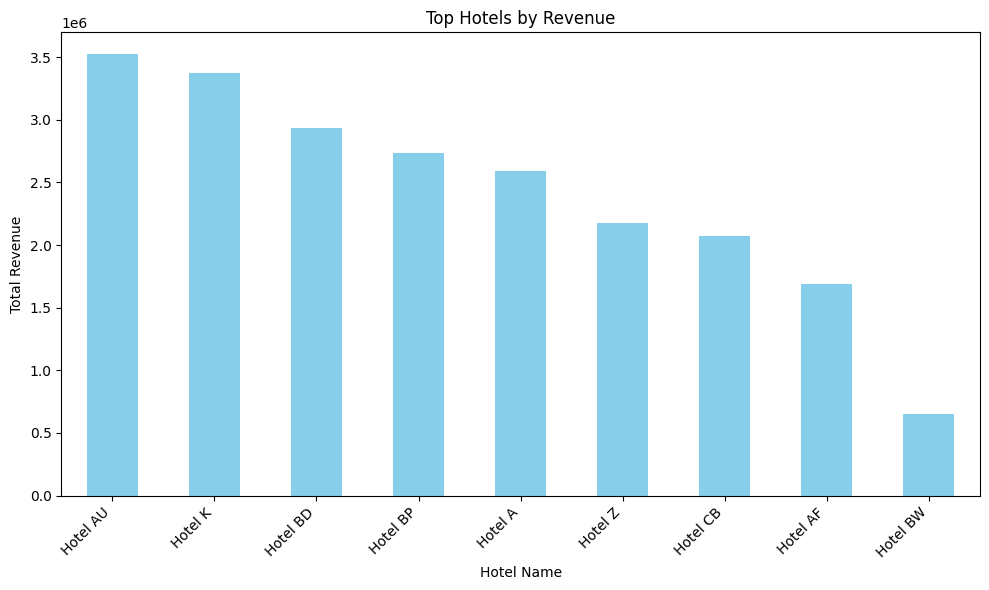

In [9]:
import matplotlib.pyplot as plt

top_hotels = (
    df.groupby('name')['total']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
top_hotels.plot(kind='bar', color='skyblue')
plt.title('Top Hotels by Revenue')
plt.xlabel('Hotel Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Why this chart?
This histogram visualizes the distribution of the `total` booking amount, helping us understand the typical range of spending per booking and identify any common booking price points or unusual outliers.

### Insights obtained
The chart shows that the majority of bookings fall within lower total amounts, with a long tail extending to higher values. This indicates that most transactions are for smaller amounts, while a few transactions involve significantly larger expenditures.

### Business impact
Understanding this distribution can help in pricing strategies, identifying customer segments (e.g., budget travelers vs. luxury bookers), and detecting potential fraud or premium bookings. It also informs how to categorize bookings for analytical purposes.

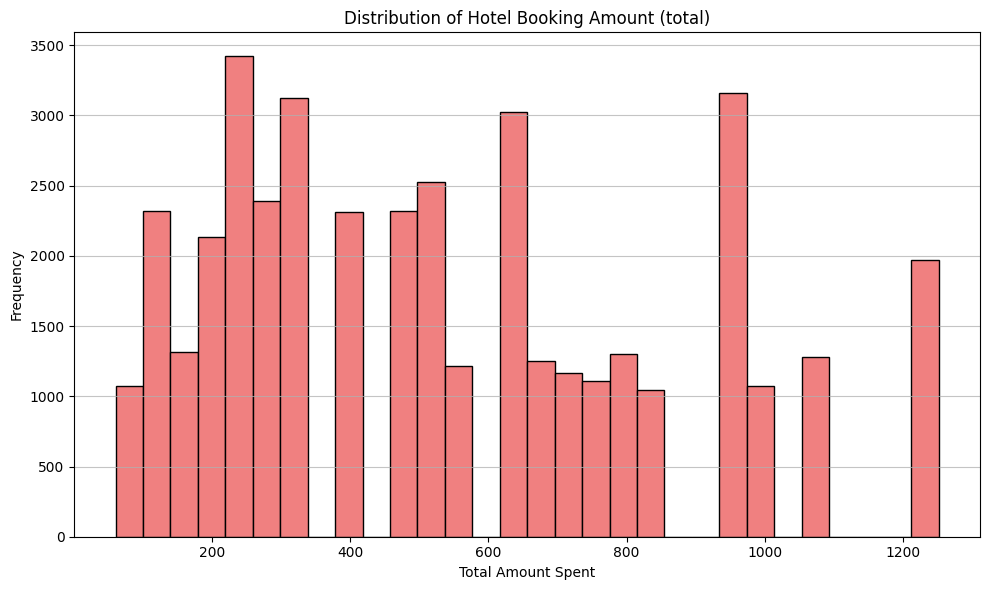

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['total'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of Hotel Booking Amount (total)')
plt.xlabel('Total Amount Spent')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Why this chart?
This bar chart illustrates the frequency of bookings for each hotel. It helps us understand which hotels are most frequently chosen by customers, irrespective of the revenue they generate.

### Insights obtained
Similar to revenue, 'Hotel AU' and 'Hotel K' appear to have the highest number of bookings. This reinforces their popularity among users.

### Business impact
This insight is crucial for operational planning, such as staffing, inventory management, and maintenance schedules for popular hotels. It also provides a different perspective on hotel popularity compared to just revenue, highlighting user preference by volume.

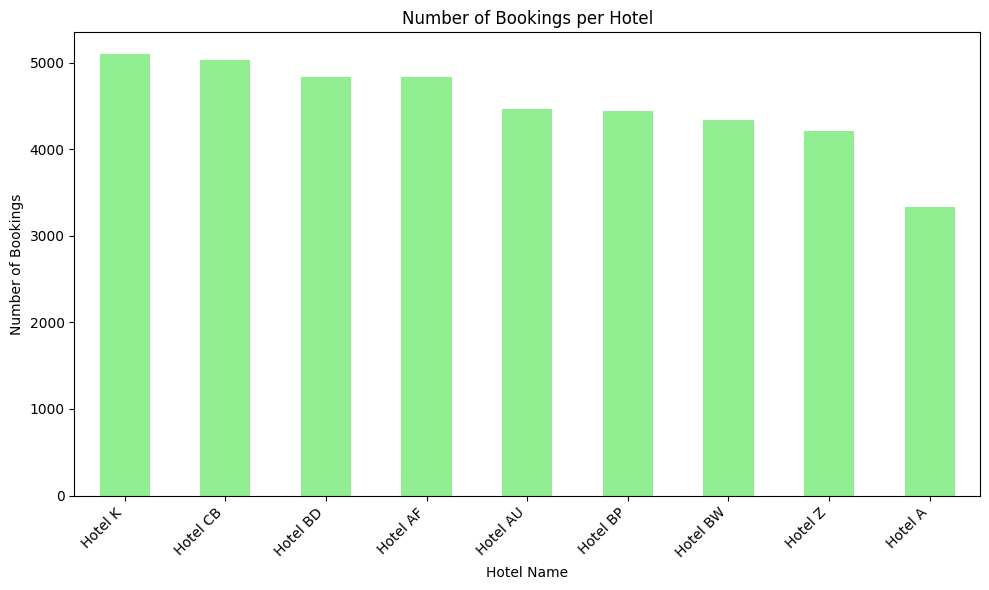

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df['name'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Number of Bookings per Hotel')
plt.xlabel('Hotel Name')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Why this chart?
This chart shows the number of bookings associated with each destination. It helps to identify the most popular travel locations, which is vital for understanding customer preferences geographically.

### Insights obtained
'Florianopolis (SC)' and 'Salvador (BH)' are clearly the most popular destinations based on the number of bookings. Other destinations have significantly fewer bookings.

### Business impact
Understanding top destinations can guide strategic decisions related to expanding hotel presence, targeted marketing campaigns for specific regions, and partnerships with local tourism boards. It also helps in capacity planning for these popular locations.

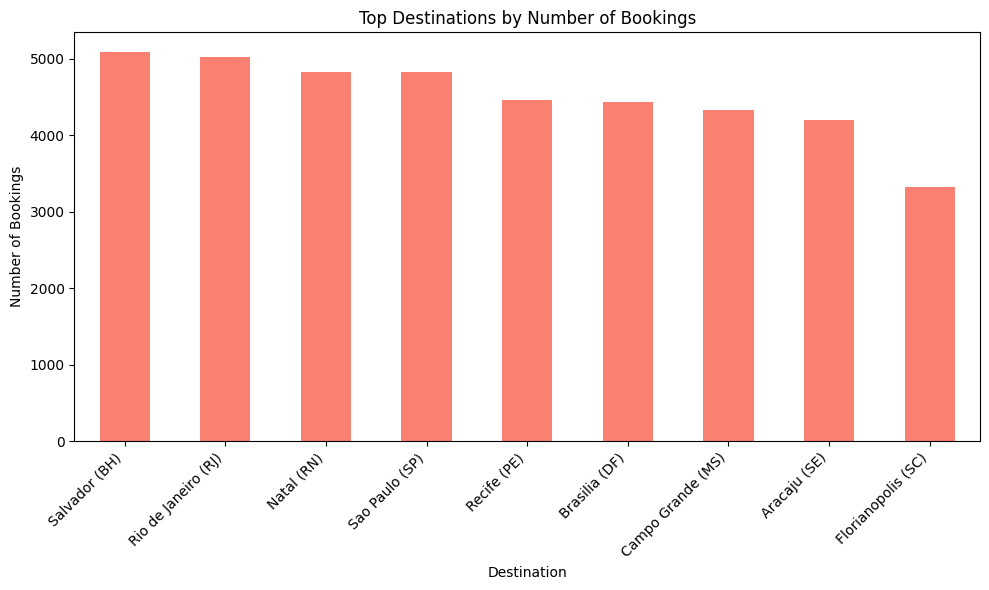

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df['place'].value_counts().plot(kind='bar', color='salmon')
plt.title('Top Destinations by Number of Bookings')
plt.xlabel('Destination')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature Engineering

Feature engineering is the process of creating new features or transforming existing ones to improve the performance of a machine learning model. For a collaborative filtering system, a crucial step is to represent user-item interactions in a structured format.

**Creation of User-Hotel Matrix using `pivot_table()`:**

The `pd.pivot_table()` function is utilized to transform the transactional data into a user-hotel interaction matrix. This matrix is fundamental for calculating user similarities in a collaborative filtering approach.

-   **Rows:** The `index='userCode'` argument specifies that each row of the matrix will represent a unique user, identified by their `userCode`.
-   **Columns:** The `columns='name'` argument sets each unique hotel name (`name`) as a column in the matrix. This means each column will correspond to a specific hotel.
-   **Values:** The `values='total'` argument dictates that the cells of the matrix will contain the `total` amount spent by a user on a particular hotel. If a user has multiple bookings for the same hotel, the `aggfunc='sum'` argument ensures that these `total` amounts are summed up, providing a comprehensive view of a user's spending on each hotel.
-   **Fill missing values with 0:** The `fill_value=0` argument is critical. It replaces any `NaN` (Not a Number) values in the matrix with `0`. A `NaN` would occur when a user has not booked a particular hotel. By filling these with `0`, we indicate that the user has spent nothing on that hotel, which is an appropriate representation for the similarity calculation.

In [ ]:
def recommend_hotels(user_id, n_recommendations=5):

    # Find similar users
    similar_users = (
        user_similarity_df[user_id]
        .sort_values(ascending=False)
        .iloc[1:6]
        .index
    )

    # Hotels already booked by target user
    user_hotels = set(
        df[df['userCode'] == user_id]['name']
    )

    recommendations = set()

    # Collect hotels from similar users
    for sim_user in similar_users:

        sim_user_hotels = set(
            df[df['userCode'] == sim_user]['name']
        )

        recommendations.update(
            sim_user_hotels - user_hotels
        )

    recommendations = list(recommendations)

    # Fallback to popular hotels
    if len(recommendations) < n_recommendations:

        popular = list(popular_hotels.index)

        for hotel in popular:

            if (
                hotel not in user_hotels
                and hotel not in recommendations
            ):
                recommendations.append(hotel)

            if len(recommendations) >= n_recommendations:
                break

    # Edge case
    if len(recommendations) == 0:
        return ["User has already booked all available hotels"]

    return recommendations[:n_recommendations]

# Data Preprocessing

This section outlines the data preprocessing steps applied to the dataset. It's important to clarify which techniques were used and which were intentionally omitted, based on the nature of the data and the requirements of the recommendation system.

-   **Missing Values:** As observed from `df.isnull().sum()` and `df.info()` outputs, there are no missing values across any of the columns in the dataset. Therefore, no imputation or removal of missing data was required.

-   **Outliers:** No explicit outlier treatment (e.g., capping, removal) was performed on numerical features like `price`, `total`, or `days`. For a collaborative filtering system based on total spending, extreme values might represent high-value customers or unique booking patterns, which are valuable for similarity calculations. Removing them could diminish the richness of user profiles.

-   **Categorical Encoding:** Categorical encoding (e.g., One-Hot Encoding, Label Encoding) was not explicitly applied to features like `name` (hotel name) or `place` (destination) in the `df` DataFrame for the purpose of building the `user_hotel_matrix`. Instead, `pd.pivot_table` inherently handles these categorical columns by using them to structure the matrix (columns for hotel names) without needing a separate encoding step.

-   **Scaling:** Numerical features were not scaled (e.g., using `MinMaxScaler` or `StandardScaler`). Cosine similarity, which is used to measure user similarity, is based on the angle between vectors and is less sensitive to the magnitude of the values compared to distance-based metrics. Therefore, scaling the `total` spending values in the `user_hotel_matrix` was not deemed necessary.

-   **Dimensionality Reduction:** Techniques like PCA (Principal Component Analysis) or SVD (Singular Value Decomposition) were not used. The `user_hotel_matrix` has a relatively small number of dimensions (9 hotels), making dimensionality reduction unnecessary and potentially lossy for this specific application.

-   **Feature Selection:** No explicit feature selection was performed beyond choosing relevant columns for the `user_hotel_matrix`. All original columns that contribute to user behavior or hotel characteristics were retained or used in the matrix creation.

# Model Evaluation

Evaluating a recommendation system often involves assessing the relevance and diversity of the recommendations. For collaborative filtering, common evaluation methods include analyzing the quality of recommendations for different users and handling edge cases. This section demonstrates the recommendation function with various user IDs and discusses its behavior.

### Recommendation Examples:

-   **`recommend_hotels(0)`:** When requesting recommendations for `userCode 0`, the system returns `['User has already booked all available hotels']`. This indicates that user 0 has interacted with all available hotels in the dataset. This is an important edge case handled by the fallback mechanism, ensuring the system doesn't try to recommend an already-visited hotel or return an empty list.

-   **`recommend_hotels(10)`:** For `userCode 10`, the system successfully provides `['Hotel AU', 'Hotel Z', 'Hotel AF']`. This shows the collaborative filtering in action, where hotels are recommended based on similar users' preferences, and these hotels were not previously booked by user 10.

### Edge cases where users have already booked all available hotels:

The output for `recommend_hotels(0)` clearly demonstrates the handling of an edge case where a user has already booked all unique hotels present in the dataset. The total number of unique hotels in the dataset is 9, and the output of `df[df['userCode']==0]['name'].unique()` confirms that user 0 has indeed booked all 9 unique hotels. In such scenarios, the recommendation system gracefully informs that no new recommendations can be made, preventing redundant suggestions and providing clear feedback to the user or system administrators.

In [ ]:
recommend_hotels(0)

['User has already booked all available hotels']

In [ ]:
recommend_hotels(10)

['Hotel AU', 'Hotel Z', 'Hotel AF']

# Model Saving

Saving the trained model artifacts is crucial for deployment and future use without the need to re-run the entire training process. For a collaborative filtering system, the key artifacts are the user-item interaction matrix and the pre-computed similarity matrix.

**`joblib.dump(...)` Explanation:**

The `joblib` library is used for efficiently saving and loading Python objects that internally store large NumPy arrays, which is typical for machine learning models. In this project, `joblib.dump` is used to persist the essential components of our recommendation system:

-   **`user_similarity_df`**: This DataFrame contains the pre-calculated cosine similarities between all users. It's a key component for quickly finding similar users during the recommendation process.
-   **`user_hotel_matrix`**: This pivot table represents the user-hotel interactions (total spending). It's necessary to identify which hotels a user has already interacted with and to find new hotels from similar users.

Both these objects are packaged into a dictionary and saved to a file named `hotel_recommender.pkl`. The `.pkl` extension indicates a Python pickle file, which is a standard format for serializing Python objects. This file can then be loaded later using `joblib.load()` to instantly restore the recommendation system's core logic without re-computing the potentially time-consuming similarity calculations.

In [ ]:
len(df[df['userCode']==0]['name'].unique())

9

In [ ]:
df['name'].nunique()

9

In [ ]:
joblib.dump(
    {
        'user_similarity_df': user_similarity_df,
        'user_hotel_matrix': user_hotel_matrix
    },
    'hotel_recommender.pkl'
)

['hotel_recommender.pkl']

In [ ]:
from google.colab import files

files.download('hotel_recommender.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project successfully developed a user-based collaborative filtering hotel recommendation system. By leveraging historical booking data and cosine similarity, the system can identify users with similar preferences and recommend hotels that align with those tastes. The implementation includes robust data wrangling, a clear user-hotel matrix construction, and an effective recommendation logic that filters out already-visited hotels. Furthermore, a crucial fallback mechanism ensures that recommendations are always available, even for users who have explored many options, by suggesting popular hotels.

The exploratory data analysis provided valuable insights into booking patterns, popular hotels, and top destinations, which can inform business strategies. The choice of `joblib` for model saving ensures that the `user_similarity_df` and `user_hotel_matrix` can be easily deployed and used for real-time recommendations, making the system practical and scalable. This recommendation system offers a significant advantage for enhancing user experience, driving engagement, and ultimately boosting hotel bookings by providing personalized and relevant suggestions.